# This one is to simulate what the LSURF is doing

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv('../data/phreeqc_example8_all_simulations.csv')
df=df.dropna()
df

,sim,specified_pH,input_Zn_mol_L,time_days,pH,TOT-H+,TOT-Zn++,TOT-Na+,TOT-NO3-,TOT-Fe+++,...,Zn(OH)4--,ZnOH+,>FeOH_str,>FeOH_weak,>FeO-_str,>FeOH2+_str,>FeOHZn+_str,>FeO-_w,>FeOH2+_w,>FeOHZn+_w
0,ph5p00_zn1e-07,5.00,1.000000e-07,365.0,4.996352,1.210717e-05,9.960889e-08,0.099988,0.1,2.598771e-09,...,2.735187e-29,5.632359e-12,2.460044e-06,0.000098,4.406788e-08,3.146036e-06,3.753899e-10,0.000002,0.000126,1.572430e-11
1,ph5p25_zn1e-07,5.25,1.000000e-07,365.0,5.246200,6.809139e-06,9.893112e-08,0.099993,0.1,4.630258e-10,...,2.712653e-28,9.943835e-12,2.842421e-06,0.000114,6.756176e-08,2.739528e-06,1.025903e-09,0.000003,0.000110,4.297787e-11
2,ph5p50_zn1e-07,5.50,1.000000e-07,365.0,5.496210,3.826110e-06,9.713167e-08,0.099996,0.1,8.246151e-11,...,2.663356e-27,1.736033e-11,3.181967e-06,0.000127,9.795688e-08,2.367862e-06,2.752968e-09,0.000004,0.000095,1.153646e-10
3,ph5p75_zn1e-07,5.75,1.000000e-07,365.0,5.746311,2.145994e-06,9.255899e-08,0.099998,0.1,1.469433e-11,...,2.539981e-26,2.942092e-11,3.470281e-06,0.000139,1.353890e-07,2.037727e-06,7.141510e-09,0.000005,0.000082,2.995013e-10
4,ph6p00_zn1e-07,6.00,1.000000e-07,365.0,5.996474,1.197283e-06,8.206505e-08,0.099999,0.1,2.622948e-12,...,2.254839e-25,4.639287e-11,3.703137e-06,0.000149,1.794382e-07,1.750752e-06,1.721183e-08,0.000007,0.000070,7.231203e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,ph7p00_zn1e-04,7.00,1.000000e-04,365.0,7.000390,-4.445536e-07,7.142152e-05,0.099858,0.1,2.813095e-15,...,2.023826e-18,4.052048e-07,3.973951e-08,0.000156,5.598490e-09,6.462107e-09,5.598739e-06,0.000022,0.000025,2.297974e-05
74,ph7p25_zn1e-04,7.25,1.000000e-04,365.0,7.250868,-8.165159e-07,5.770633e-05,0.099885,0.1,5.383830e-16,...,1.634481e-17,5.800511e-07,2.305543e-08,0.000144,4.783967e-09,2.545413e-09,5.620155e-06,0.000030,0.000016,3.667352e-05
75,ph7p50_zn1e-04,7.50,1.000000e-04,365.0,7.501363,-1.320143e-06,4.378814e-05,0.099914,0.1,1.079679e-16,...,1.234675e-16,7.765502e-07,1.473125e-08,0.000126,4.646841e-09,1.069847e-09,5.630091e-06,0.000040,0.000009,5.058177e-05
76,ph7p75_zn1e-04,7.75,1.000000e-04,365.0,7.751892,-2.058269e-06,3.134436e-05,0.099939,0.1,2.309149e-17,...,8.725713e-16,9.724032e-07,1.000640e-08,0.000107,4.775784e-09,4.802985e-10,5.635277e-06,0.000051,0.000005,6.302036e-05


In [25]:
df = df.rename(columns={'specified_pH':'input_pH','input_Zn_mol_L':'zn','SURF-H+':'h_sorbed','SURF-Zn++':'zn_sorbed'})
df['h']=10**(-df['input_pH'])
df


,sim,input_pH,zn,time_days,pH,TOT-H+,TOT-Zn++,TOT-Na+,TOT-NO3-,TOT-Fe+++,...,ZnOH+,>FeOH_str,>FeOH_weak,>FeO-_str,>FeOH2+_str,>FeOHZn+_str,>FeO-_w,>FeOH2+_w,>FeOHZn+_w,h
0,ph5p00_zn1e-07,5.00,1.000000e-07,365.0,4.996352,1.210717e-05,9.960889e-08,0.099988,0.1,2.598771e-09,...,5.632359e-12,2.460044e-06,0.000098,4.406788e-08,3.146036e-06,3.753899e-10,0.000002,0.000126,1.572430e-11,1.000000e-05
1,ph5p25_zn1e-07,5.25,1.000000e-07,365.0,5.246200,6.809139e-06,9.893112e-08,0.099993,0.1,4.630258e-10,...,9.943835e-12,2.842421e-06,0.000114,6.756176e-08,2.739528e-06,1.025903e-09,0.000003,0.000110,4.297787e-11,5.623413e-06
2,ph5p50_zn1e-07,5.50,1.000000e-07,365.0,5.496210,3.826110e-06,9.713167e-08,0.099996,0.1,8.246151e-11,...,1.736033e-11,3.181967e-06,0.000127,9.795688e-08,2.367862e-06,2.752968e-09,0.000004,0.000095,1.153646e-10,3.162278e-06
3,ph5p75_zn1e-07,5.75,1.000000e-07,365.0,5.746311,2.145994e-06,9.255899e-08,0.099998,0.1,1.469433e-11,...,2.942092e-11,3.470281e-06,0.000139,1.353890e-07,2.037727e-06,7.141510e-09,0.000005,0.000082,2.995013e-10,1.778279e-06
4,ph6p00_zn1e-07,6.00,1.000000e-07,365.0,5.996474,1.197283e-06,8.206505e-08,0.099999,0.1,2.622948e-12,...,4.639287e-11,3.703137e-06,0.000149,1.794382e-07,1.750752e-06,1.721183e-08,0.000007,0.000070,7.231203e-10,1.000000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,ph7p00_zn1e-04,7.00,1.000000e-04,365.0,7.000390,-4.445536e-07,7.142152e-05,0.099858,0.1,2.813095e-15,...,4.052048e-07,3.973951e-08,0.000156,5.598490e-09,6.462107e-09,5.598739e-06,0.000022,0.000025,2.297974e-05,1.000000e-07
74,ph7p25_zn1e-04,7.25,1.000000e-04,365.0,7.250868,-8.165159e-07,5.770633e-05,0.099885,0.1,5.383830e-16,...,5.800511e-07,2.305543e-08,0.000144,4.783967e-09,2.545413e-09,5.620155e-06,0.000030,0.000016,3.667352e-05,5.623413e-08
75,ph7p50_zn1e-04,7.50,1.000000e-04,365.0,7.501363,-1.320143e-06,4.378814e-05,0.099914,0.1,1.079679e-16,...,7.765502e-07,1.473125e-08,0.000126,4.646841e-09,1.069847e-09,5.630091e-06,0.000040,0.000009,5.058177e-05,3.162278e-08
76,ph7p75_zn1e-04,7.75,1.000000e-04,365.0,7.751892,-2.058269e-06,3.134436e-05,0.099939,0.1,2.309149e-17,...,9.724032e-07,1.000640e-08,0.000107,4.775784e-09,4.802985e-10,5.635277e-06,0.000051,0.000005,6.302036e-05,1.778279e-08


In [26]:

output_columns = ['h_sorbed', 'zn_sorbed']
y = df[output_columns]

In [27]:
y

,h_sorbed,zn_sorbed
0,0.000127,3.911142e-10
1,0.000110,1.068880e-09
2,0.000093,2.868332e-09
3,0.000078,7.441011e-09
4,0.000065,1.793495e-08
...,...,...
73,-0.000025,2.857848e-05
74,-0.000056,4.229367e-05
75,-0.000087,5.621186e-05
76,-0.000115,6.865564e-05


In [28]:
df = df.drop(columns=['sim','input_pH','time_days','pH','h_sorbed','zn_sorbed'])

In [29]:
zero_columns = df.columns[(df == 0).all()]
df = df.drop(columns=zero_columns)
df

,zn,TOT-H+,TOT-Zn++,TOT-Na+,TOT-NO3-,TOT-Fe+++,TOT-O2(aq),H+,Zn++,Na+,...,ZnOH+,>FeOH_str,>FeOH_weak,>FeO-_str,>FeOH2+_str,>FeOHZn+_str,>FeO-_w,>FeOH2+_w,>FeOHZn+_w,h
0,1.000000e-07,1.210717e-05,9.960889e-08,0.099988,0.1,2.598771e-09,0.000246,1.210849e-05,9.960327e-08,0.099988,...,5.632359e-12,2.460044e-06,0.000098,4.406788e-08,3.146036e-06,3.753899e-10,0.000002,0.000126,1.572430e-11,1.000000e-05
1,1.000000e-07,6.809139e-06,9.893112e-08,0.099993,0.1,4.630258e-10,0.000246,6.811492e-06,9.892119e-08,0.099993,...,9.943835e-12,2.842421e-06,0.000114,6.756176e-08,2.739528e-06,1.025903e-09,0.000003,0.000110,4.297787e-11,5.623413e-06
2,1.000000e-07,3.826110e-06,9.713167e-08,0.099996,0.1,8.246151e-11,0.000246,3.830293e-06,9.711431e-08,0.099996,...,1.736033e-11,3.181967e-06,0.000127,9.795688e-08,2.367862e-06,2.752968e-09,0.000004,0.000095,1.153646e-10,3.162278e-06
3,1.000000e-07,2.145994e-06,9.255899e-08,0.099998,0.1,1.469433e-11,0.000246,2.153431e-06,9.252954e-08,0.099998,...,2.942092e-11,3.470281e-06,0.000139,1.353890e-07,2.037727e-06,7.141510e-09,0.000005,0.000082,2.995013e-10,1.778279e-06
4,1.000000e-07,1.197283e-06,8.206505e-08,0.099999,0.1,2.622948e-12,0.000246,1.210508e-06,8.201853e-08,0.099999,...,4.639287e-11,3.703137e-06,0.000149,1.794382e-07,1.750752e-06,1.721183e-08,0.000007,0.000070,7.231203e-10,1.000000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,1.000000e-04,-4.445536e-07,7.142152e-05,0.099858,0.1,2.813095e-15,0.000246,1.199676e-07,7.100316e-05,0.099858,...,4.052048e-07,3.973951e-08,0.000156,5.598490e-09,6.462107e-09,5.598739e-06,0.000022,0.000025,2.297974e-05,1.000000e-07
74,1.000000e-04,-8.165159e-07,5.770633e-05,0.099885,0.1,5.383830e-16,0.000246,6.738827e-08,5.709272e-05,0.099885,...,5.800511e-07,2.305543e-08,0.000144,4.783967e-09,2.545413e-09,5.620155e-06,0.000030,0.000016,3.667352e-05,5.623413e-08
75,1.000000e-04,-1.320143e-06,4.378814e-05,0.099914,0.1,1.079679e-16,0.000246,3.785178e-08,4.293160e-05,0.099914,...,7.765502e-07,1.473125e-08,0.000126,4.646841e-09,1.069847e-09,5.630091e-06,0.000040,0.000009,5.058177e-05,3.162278e-08
76,1.000000e-04,-2.058269e-06,3.134436e-05,0.099939,0.1,2.309149e-17,0.000246,2.125961e-08,3.019360e-05,0.099939,...,9.724032e-07,1.000640e-08,0.000107,4.775784e-09,4.802985e-10,5.635277e-06,0.000051,0.000005,6.302036e-05,1.778279e-08


In [30]:
X = df[['h','zn','Zn(OH)2(aq)','Zn(OH)3-','Zn(OH)4--','ZnOH+','Zn++','Na+','NO3-','Fe+++','Fe++','O2(aq)']]

In [31]:
X

,h,zn,Zn(OH)2(aq),Zn(OH)3-,Zn(OH)4--,ZnOH+,Zn++,Na+,NO3-,Fe+++,Fe++,O2(aq)
0,1.000000e-05,1.000000e-07,1.813505e-15,7.349991e-22,2.735187e-29,5.632359e-12,9.960327e-08,0.099988,0.1,2.595839e-09,2.932403e-12,0.000246
1,5.623413e-06,1.000000e-07,5.691547e-15,4.100588e-21,2.712653e-28,9.943835e-12,9.892119e-08,0.099993,0.1,4.620980e-10,9.279570e-13,0.000246
2,3.162278e-06,1.000000e-07,1.767034e-14,2.263971e-20,2.663356e-27,1.736033e-11,9.711431e-08,0.099996,0.1,8.216810e-11,2.934319e-13,0.000246
3,1.778279e-06,1.000000e-07,5.326525e-14,1.213867e-19,2.539981e-26,2.942092e-11,9.252954e-08,0.099998,0.1,1.460159e-11,9.274816e-14,0.000246
4,1.000000e-06,1.000000e-07,1.494178e-13,6.057492e-19,2.254839e-25,4.639287e-11,8.201853e-08,0.099999,0.1,2.593642e-12,2.930748e-14,0.000246
...,...,...,...,...,...,...,...,...,...,...,...,...
73,1.000000e-07,1.000000e-04,1.316767e-08,5.387018e-13,2.023826e-18,4.052048e-07,7.100316e-05,0.099858,0.1,2.525205e-15,2.878914e-16,0.000246
74,5.623413e-08,1.000000e-04,3.355708e-08,2.443962e-12,1.634481e-17,5.800511e-07,5.709272e-05,0.099885,0.1,4.475472e-16,9.083606e-17,0.000246
75,3.162278e-08,1.000000e-04,7.998149e-08,1.037024e-11,1.234675e-16,7.765502e-07,4.293160e-05,0.099914,0.1,7.930960e-17,2.865834e-17,0.000246
76,1.778279e-08,1.000000e-04,1.783203e-07,4.116453e-11,8.725713e-16,9.724032e-07,3.019360e-05,0.099939,0.1,1.405128e-17,9.040222e-18,0.000246


## Train test split

In [32]:
from sklearn.model_selection import train_test_split
random_seed = 270
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=random_seed)

In [33]:
print(X_test)

               h            zn   Zn(OH)2(aq)      Zn(OH)3-     Zn(OH)4--  \
58  3.162278e-07  2.511886e-05  3.516467e-10  4.526076e-15  5.349137e-21   
22  5.623413e-08  3.981072e-07  6.705303e-12  4.852233e-16  3.224017e-21   
74  5.623413e-08  1.000000e-04  3.355708e-08  2.443962e-12  1.634481e-17   
17  1.000000e-06  3.981072e-07  5.958531e-13  2.415760e-18  8.992919e-25   
42  1.778279e-06  6.309573e-06  3.381463e-12  7.709317e-18  1.613852e-24   
49  3.162278e-08  6.309573e-06  6.042895e-10  7.791413e-14  9.224020e-19   
55  1.778279e-06  2.511886e-05  1.364903e-11  3.114108e-17  6.524024e-24   
43  1.000000e-06  6.309573e-06  9.720920e-12  3.944283e-17  1.469485e-23   

           ZnOH+          Zn++       Na+  NO3-         Fe+++          Fe++  \
58  3.439128e-08  1.915177e-05  0.099961   0.1  8.105848e-14  2.907828e-15   
22  1.166365e-10  1.155215e-08  0.100000   0.1  4.560496e-16  9.198419e-17   
74  5.800511e-07  5.709272e-05  0.099885   0.1  4.475472e-16  9.083606e-17   
17 

In [34]:
rng = np.random.default_rng(random_seed)
sigma = 0.01
number = 120

noisy_inputs =[X_train.to_numpy()]  

for _ in range(number):
    noise = rng.normal(-0.5 * sigma**2, sigma,X_train.shape)
    noisy_inputs.append(X_train.to_numpy() * np.exp(noise))

X_train_noise = np.vstack(noisy_inputs)
y_train_noise = np.tile(y_train.to_numpy(), (number+1,1))


In [35]:
X_train_noise

array([[1.00000000e-07, 1.58489319e-06, 2.72960488e-11, ...,
        2.57124289e-15, 2.91385010e-16, 2.46470028e-04],
       [1.77827941e-08, 1.58489319e-06, 4.33409037e-11, ...,
        1.42998438e-17, 9.14659150e-18, 2.46470028e-04],
       [3.16227766e-07, 6.30957344e-06, 6.17826298e-11, ...,
        8.13597266e-14, 2.91503957e-15, 2.46470028e-04],
       ...,
       [3.16130059e-08, 3.99743990e-07, 7.58204367e-12, ...,
        7.95803774e-17, 2.83674657e-17, 2.45460571e-04],
       [1.76507792e-07, 9.94150731e-05, 4.76944692e-09, ...,
        1.42397006e-14, 9.06752604e-16, 2.46219409e-04],
       [3.12638827e-07, 1.60231773e-06, 1.22148527e-11, ...,
        8.18027274e-14, 2.95341241e-15, 2.44373604e-04]], shape=(8470, 12))

In [36]:
y_train_noise

array([[2.23745711e-05, 1.43505109e-06],
       [2.73548795e-06, 1.57718724e-06],
       [3.70195601e-05, 2.93026017e-06],
       ...,
       [1.07551516e-05, 3.93873420e-07],
       [2.20977264e-06, 1.75411707e-05],
       [4.05629149e-05, 9.21321618e-07]], shape=(8470, 2))

In [37]:
from sklearn.preprocessing import StandardScaler

x_scalar = StandardScaler()
y_scalar = StandardScaler()

x_scalar.fit(X_train)
y_scalar.fit(y_train)

X_train_scale = x_scalar.transform(X_train_noise)
y_train_scale = y_scalar.transform(y_train_noise)

X_test_scale = x_scalar.transform(X_test)
y_test_scale = y_scalar.transform(y_test)

/home/zfeng3/miniconda3/envs/geochem_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/zfeng3/miniconda3/envs/geochem_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [39]:
print(X_test_scale)

[[-5.20924777e-01  7.57631761e-02 -1.96601399e-01 -1.65880510e-01
  -1.47591167e-01 -1.44917463e-01  1.01485284e-01 -7.21967760e-02
   1.38777878e-17 -3.73290710e-01 -4.36012918e-01 -4.35037235e-01]
 [-6.08012029e-01 -6.04824341e-01 -2.03634444e-01 -1.66097683e-01
  -1.47594265e-01 -3.14733428e-01 -5.28732822e-01  5.58989200e-01
   1.38777878e-17 -3.73402122e-01 -4.39412359e-01 -4.38901185e-01]
 [-6.08012029e-01  2.13731679e+00  4.80427538e-01 -3.47744926e-02
  -1.23776038e-01  2.55858956e+00  1.35074388e+00 -1.30796144e+00
   1.38777878e-17 -3.73402134e-01 -4.39413746e-01 -4.38901185e-01]
 [-2.91888996e-01 -6.04824341e-01 -2.03759010e-01 -1.66123632e-01
  -1.47598963e-01 -3.14394732e-01 -5.18344938e-01  5.26660088e-01
   1.38777878e-17 -3.69818296e-01 -4.04145680e-01 -4.05090773e-01]
 [-3.11971690e-02 -4.42075679e-01 -2.03702214e-01 -1.66123347e-01
  -1.47598962e-01 -3.06061268e-01 -3.35858661e-01  3.31017712e-01
   1.38777878e-17 -3.53244565e-01 -3.27644522e-01 -3.29258695e-01]
 [-6.

In [82]:
X_train_scale

array([[-5.93352250e-01, -5.72150918e-01, -2.03214617e-01, ...,
        -3.73399198e-01, -4.39171632e-01, -4.37935263e-01],
       [-6.20891657e-01, -5.72150918e-01, -2.02887477e-01, ...,
        -3.73402732e-01, -4.39512366e-01, -4.39867369e-01],
       [-5.20924777e-01, -4.42075679e-01, -2.02511467e-01, ...,
        -3.73290293e-01, -4.36004212e-01, -4.35037235e-01],
       ...,
       [-6.16259101e-01, -6.04779277e-01, -2.03616568e-01, ...,
        -3.73402642e-01, -4.39489161e-01, -4.87574875e+06],
       [-5.67725264e-01,  2.12121316e+00, -1.06526432e-01, ...,
        -3.73383069e-01, -4.38428726e-01, -1.21050790e+06],
       [-5.22126925e-01, -5.71671203e-01, -2.03522109e-01, ...,
        -3.73289681e-01, -4.35957886e-01, -1.01258716e+07]],
      shape=(8470, 12))

In [83]:
y_train_scale

array([[-0.32104402, -0.32877532],
       [-0.67360454, -0.3190167 ],
       [-0.05813739, -0.22611902],
       ...,
       [-0.52963566, -0.40025926],
       [-0.68304218,  0.77701958],
       [ 0.00547286, -0.36404635]], shape=(8470, 2))

In [84]:
X_train_scale = pd.DataFrame(X_train_scale, columns=X.columns)

In [85]:
X_train_scale

,h,zn,Zn(OH)2(aq),Zn(OH)3-,Zn(OH)4--,ZnOH+,Zn++,Na+,NO3-,Fe+++,Fe++,O2(aq)
0,-0.593352,-0.572151,-0.203215,-0.166064,-0.147593,-0.311124,-0.524208,0.552015,1.387779e-17,-0.373399,-0.439172,-4.379353e-01
1,-0.620892,-0.572151,-0.202887,-0.165589,-0.147294,-0.314133,-0.528869,0.568189,1.387779e-17,-0.373403,-0.439512,-4.398674e-01
2,-0.520925,-0.442076,-0.202511,-0.166081,-0.147598,-0.285337,-0.418046,0.441695,1.387779e-17,-0.373290,-0.436004,-4.350372e-01
3,-0.438487,-0.572151,-0.203650,-0.166121,-0.147599,-0.310192,-0.495320,0.512742,1.387779e-17,-0.372767,-0.428355,-4.282750e-01
4,2.722744,2.137317,-0.203734,-0.166124,-0.147599,-0.287397,2.751231,-2.883170,1.387779e-17,3.213612,3.099846,3.100089e+00
...,...,...,...,...,...,...,...,...,...,...,...,...
8465,-0.520095,-0.612994,-0.203757,-0.166123,-0.147599,-0.314978,-0.527849,24.568652,-8.701405e-04,-0.373289,-0.435986,-5.644527e+06
8466,-0.593124,-0.443389,-0.198472,-0.165556,-0.147542,-0.275545,-0.482202,20.482168,-2.317625e-03,-0.373399,-0.439174,-1.301894e+07
8467,-0.616259,-0.604779,-0.203617,-0.166071,-0.147582,-0.314938,-0.528976,-8.885155,-1.267028e-03,-0.373403,-0.439489,-4.875749e+06
8468,-0.567725,2.121213,-0.106526,-0.160194,-0.147261,0.981669,2.188055,-10.405199,-1.768064e-03,-0.373383,-0.438429,-1.210508e+06


In [86]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import RandomizedSearchCV

def rf_regressor_train(tolerance, X_train_scale, y_train_scale):
    rf = RandomForestRegressor(bootstrap=True, criterion='squared_error',random_state=random_seed)

    # ==================================
    # Feature Selection
    # ==================================

    sfs_backward = SequentialFeatureSelector(
        estimator=rf,
        n_features_to_select=tolerance,
        direction='backward',
        cv=10,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    sfs_backward.fit(X_train_scale,y_train_scale)
    
    selected_feat_mask = sfs_backward.get_support() # [True, False, True, False]
    selected_features = X_train_scale.columns[selected_feat_mask]   #['h', 'zn', ...]
    print(f'Selection status: {list(selected_features)}')
    
    X_train_selected = X_train_scale[selected_features]
    
    # ===================================
    # Hyperparameter tuning
    # ===================================

    param_distributions = {
        'n_estimators':[100, 200, 300, 400],
        'max_depth': [10, 35, 60, 85, 110, None],
        'min_samples_split': [2, 5, 10, 15, 100],
        'min_samples_leaf': [1, 2, 5, 10]
    }

    rf_random = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_distributions,
        n_iter=20,
        cv=10,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        random_state=random_seed,
        verbose=3,
        return_train_score=True,
    )

    rf_random.fit(X_train_selected, y_train_scale)
    
    best_rf_model = rf_random.best_estimator_
    best_params = rf_random.best_params_
    
    return best_rf_model, best_params, selected_features


In [87]:

import json
import joblib


feature_number = 10

best_params = []
selected_feature = []

# for i in range(feature_number):
#     train = rf_regressor_train(i + 1, X_train_scale, y_train_scale)
#     model = train[0]
#     best_params.append(train[1])
#     selected_feature.append(train[2])
#     joblib.dump(model,f'../models/surf/surf_zn_h_{i + 1}.joblib')

In [94]:
serializable_features = [list(feat) for feat in selected_feature]
with open('../models/surf/metadata.json','w') as f:
    json.dump(
        {
            'selected_features': serializable_features,
            'best_params': best_params
        }, f, indent=4
    )

In [15]:
import os
save_dir = '../models/alsurf_rf'
os.makedirs(save_dir,exist_ok=True)
joblib.dump(x_scalar,os.path.join(save_dir,'x_scalar.joblib'))
joblib.dump(y_scalar,os.path.join(save_dir,'y_scalar.joblib'))

['../models/alsurf_rf/y_scalar.joblib']

In [95]:
selected_feature

[]

In [96]:
serializable_features

[['Zn(OH)2(aq)'],
 ['Zn(OH)2(aq)', 'Fe++'],
 ['Zn(OH)2(aq)', 'Zn(OH)4--', 'Fe++'],
 ['Zn(OH)2(aq)', 'Zn(OH)3-', 'Zn(OH)4--', 'Fe++'],
 ['Zn(OH)2(aq)', 'Zn(OH)3-', 'Zn(OH)4--', 'NO3-', 'Fe++'],
 ['Zn(OH)2(aq)', 'Zn(OH)3-', 'Zn(OH)4--', 'Zn++', 'NO3-', 'Fe++'],
 ['Zn(OH)2(aq)', 'Zn(OH)3-', 'Zn(OH)4--', 'Zn++', 'Na+', 'NO3-', 'Fe++'],
 ['Zn(OH)2(aq)',
  'Zn(OH)3-',
  'Zn(OH)4--',
  'ZnOH+',
  'Zn++',
  'Na+',
  'NO3-',
  'Fe++'],
 ['Zn(OH)2(aq)',
  'Zn(OH)3-',
  'Zn(OH)4--',
  'ZnOH+',
  'Zn++',
  'Na+',
  'NO3-',
  'Fe++',
  'O2(aq)'],
 ['zn',
  'Zn(OH)2(aq)',
  'Zn(OH)3-',
  'Zn(OH)4--',
  'ZnOH+',
  'Zn++',
  'Na+',
  'NO3-',
  'Fe++',
  'O2(aq)']]

In [97]:
best_params

[{'n_estimators': 100,
  'min_samples_split': 100,
  'min_samples_leaf': 2,
  'max_depth': 110},
 {'n_estimators': 100,
  'min_samples_split': 10,
  'min_samples_leaf': 1,
  'max_depth': None},
 {'n_estimators': 100,
  'min_samples_split': 10,
  'min_samples_leaf': 1,
  'max_depth': None},
 {'n_estimators': 100,
  'min_samples_split': 10,
  'min_samples_leaf': 1,
  'max_depth': None},
 {'n_estimators': 100,
  'min_samples_split': 10,
  'min_samples_leaf': 1,
  'max_depth': None},
 {'n_estimators': 100,
  'min_samples_split': 10,
  'min_samples_leaf': 1,
  'max_depth': None},
 {'n_estimators': 100,
  'min_samples_split': 10,
  'min_samples_leaf': 1,
  'max_depth': None},
 {'n_estimators': 100,
  'min_samples_split': 10,
  'min_samples_leaf': 1,
  'max_depth': None},
 {'n_estimators': 100,
  'min_samples_split': 10,
  'min_samples_leaf': 1,
  'max_depth': None},
 {'n_estimators': 100,
  'min_samples_split': 10,
  'min_samples_leaf': 1,
  'max_depth': None}]

In [21]:
X_test_scale = pd.DataFrame(X_test_scale,columns=X_test.columns)

In [22]:
X_test_scale

,h,zn,Zn(OH)2(aq),Zn(OH)3-,Zn(OH)4--,ZnOH+,Zn++,Na+,NO3-,Fe+++,Fe++,O2(aq)
0,-0.520925,0.075763,-0.196601,-0.165881,-0.147591,-0.144917,0.101485,-0.072197,1.387779e-17,-0.373291,-0.436013,-0.435037
1,-0.608012,-0.604824,-0.203634,-0.166098,-0.147594,-0.314733,-0.528733,0.558989,1.387779e-17,-0.373402,-0.439412,-0.438901
2,-0.608012,2.137317,0.480428,-0.034774,-0.123776,2.558590,1.350744,-1.307961,1.387779e-17,-0.373402,-0.439414,-0.438901
3,-0.291889,-0.604824,-0.203759,-0.166124,-0.147599,-0.314395,-0.518345,0.526660,1.387779e-17,-0.369818,-0.404146,-0.405091
4,-0.031197,-0.442076,-0.203702,-0.166123,-0.147599,-0.306061,-0.335859,0.331018,1.387779e-17,-0.353245,-0.327645,-0.329259
5,-0.616256,-0.442076,-0.191450,-0.161936,-0.146255,-0.286082,-0.518315,0.552185,1.387779e-17,-0.373403,-0.439488,-0.439384
6,-0.031197,0.075763,-0.203493,-0.166122,-0.147599,-0.278000,0.249864,-0.248015,1.387779e-17,-0.353286,-0.327800,-0.329259
7,-0.291889,-0.442076,-0.203573,-0.166122,-0.147599,-0.300370,-0.353712,0.364129,1.387779e-17,-0.369827,-0.404201,-0.405091


In [ ]:
model = []
val_predict = []
train_predict = []
for i in range(feature_number):
    model.append(joblib.load(f'../models/alsurf_rf/alsurf_{i + 1}.joblib'))
    X_test = X_test_scale[serializable_features[i]]
    X_train = X_train_scale[serializable_features[i]]
    
    # Train
    y_predict_scale = model[i].predict(X_train)
    y_predict = y_scalar.inverse_transform(y_predict_scale)
    train_predict.append(y_predict)
    

    # Val
    y_predict_scale = model[i].predict(X_test)
    y_predict = y_scalar.inverse_transform(y_predict_scale)
    val_predict.append(y_predict)
    

In [108]:
val_predict

[array([[ 7.82640538e-06,  5.56076158e-06],
        [ 5.17394362e-05,  5.57740758e-07],
        [-4.35552891e-05,  2.41345598e-05],
        [ 4.20825438e-05,  6.19080474e-08],
        [ 4.17613189e-05,  2.43483959e-07],
        [ 4.01132455e-05,  7.20295352e-06],
        [ 4.05629149e-05,  9.21321618e-07],
        [-7.23830678e-07,  3.97555245e-07]]),
 array([[ 3.35839630e-05,  5.72373617e-06],
        [ 1.76627930e-05,  9.72129285e-08],
        [-3.15228784e-05,  2.17081833e-05],
        [ 6.45977920e-05,  1.79349512e-08],
        [ 7.78934299e-05,  1.15968987e-07],
        [-5.61604591e-06,  6.17664629e-06],
        [ 7.78934299e-05,  1.15968987e-07],
        [ 6.41462856e-05,  2.74206600e-07]]),
 array([[ 1.95733334e-05,  4.90879085e-06],
        [ 1.53463596e-05,  1.17443282e-06],
        [-2.77641915e-05,  2.37365234e-05],
        [ 6.45977920e-05,  1.79349512e-08],
        [ 7.78934299e-05,  1.15968987e-07],
        [ 6.22325828e-07,  6.74804533e-06],
        [ 7.78934299e-05,  1

In [107]:
y_train_raw = y_scalar.inverse_transform(y_train_scale)

## Calculate the performance of the model

In [ ]:

val_r2 = []
val_rmse = []
val_mae = []

train_r2 = []
train_rmse = []
train_mae = []
for i in range(feature_number):
    
    # Train
    train_r2.append(r2_score(y_train_raw, train_predict[i]))
    train_rmse.append(np.sqrt(mean_squared_error(y_train_raw, train_predict[i])))
    train_mae.append(mean_absolute_error(y_train_raw, train_predict[i]))
    
    # Val
    model_r2 = r2_score(y_test, val_predict[i])
    val_r2.append(model_r2)
    model_rmse = np.sqrt(mean_squared_error(y_test, val_predict[i]))
    val_rmse.append(model_rmse)
    model_mae = mean_absolute_error(y_test, val_predict[i])
    val_mae.append(model_mae)
    print(f'=====================')
    print(f'=== Model Evaluation ===')
    print(f"R² Score: {model_r2:.4f}")
    print(f"RMSE:     {model_rmse:.4e} mol/L")
    print(f"MAE:      {model_mae:.4e} mol/L")

=== Model Evaluation ===
R² Score: 0.5325
RMSE:     2.6053e-05 mol/L
MAE:      1.8033e-05 mol/L
=== Model Evaluation ===
R² Score: 0.8308
RMSE:     8.2455e-06 mol/L
MAE:      3.8306e-06 mol/L
=== Model Evaluation ===
R² Score: 0.8471
RMSE:     9.0800e-06 mol/L
MAE:      4.3929e-06 mol/L
=== Model Evaluation ===
R² Score: 0.8430
RMSE:     8.5044e-06 mol/L
MAE:      4.2583e-06 mol/L
=== Model Evaluation ===
R² Score: 0.8466
RMSE:     8.5047e-06 mol/L
MAE:      4.1944e-06 mol/L
=== Model Evaluation ===
R² Score: 0.8724
RMSE:     8.3567e-06 mol/L
MAE:      3.9753e-06 mol/L
=== Model Evaluation ===
R² Score: 0.8758
RMSE:     8.4706e-06 mol/L
MAE:      4.0374e-06 mol/L
=== Model Evaluation ===
R² Score: 0.8751
RMSE:     8.4774e-06 mol/L
MAE:      4.1278e-06 mol/L
=== Model Evaluation ===
R² Score: 0.8814
RMSE:     8.4486e-06 mol/L
MAE:      4.0831e-06 mol/L
=== Model Evaluation ===
R² Score: 0.8754
RMSE:     8.6212e-06 mol/L
MAE:      4.1454e-06 mol/L


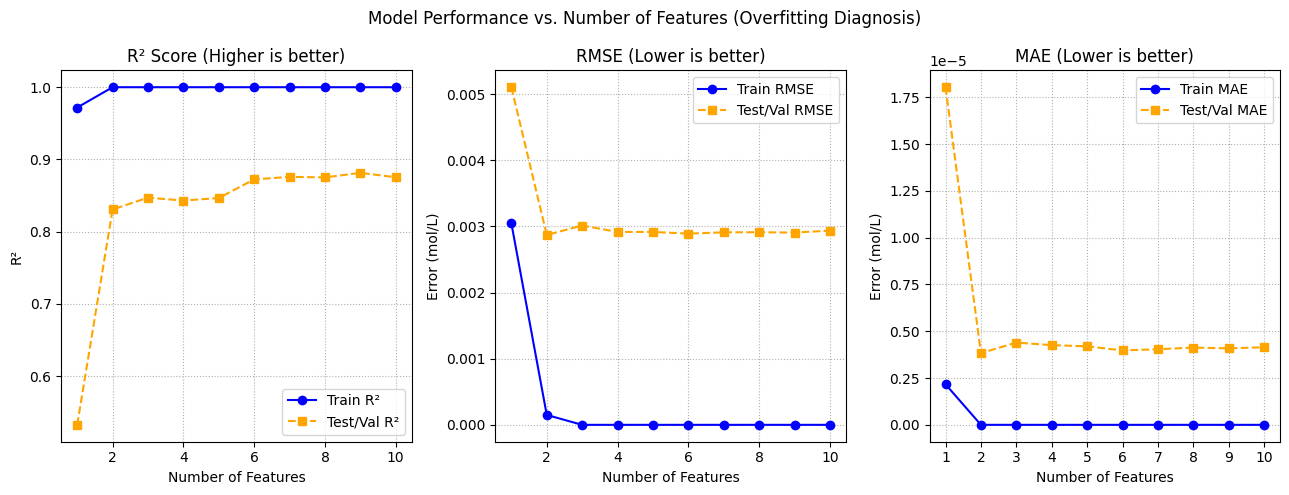

In [136]:
import matplotlib.pyplot as plt

x_features = range(1,feature_number+1)
fig, axes = plt.subplots(1, 3, figsize=(13,5))
fig.suptitle("Model Performance vs. Number of Features (Overfitting Diagnosis)")

# =================
# === R² ===
# =================
axes[0].plot(x_features, train_r2, marker='o',color='blue', label='Train R²')
axes[0].plot(x_features, val_r2, marker='s', linestyle='--', color='orange', label='Test/Val R²')
axes[0].set_title('R² Score (Higher is better)', fontsize=12)
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('R²')
axes[0].legend()
axes[0].grid(True, linestyle=':')

# =================
# === RMSE ===
# =================
axes[1].plot(x_features, np.sqrt(train_rmse), marker='o', color='blue', label='Train RMSE')
axes[1].plot(x_features, np.sqrt(val_rmse), marker='s', linestyle='--', color='orange', label='Test/Val RMSE')
axes[1].set_title('RMSE (Lower is better)')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Error (mol/L)')
axes[1].legend()
axes[1].grid(True, linestyle=':')

# =================
# === MAE ===
# =================
axes[2].plot(x_features, train_mae, marker='o', color='blue', label='Train MAE')
axes[2].plot(x_features, val_mae, marker='s', linestyle='--', color='orange', label='Test/Val MAE')
axes[2].set_title('MAE (Lower is better)')
axes[2].set_xlabel('Number of Features')
axes[2].set_ylabel('Error (mol/L)')
axes[2].set_xticks(x_features)
axes[2].legend()
axes[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()


In [90]:
X_test_scale

,h,zn,Zn(OH)2(aq),Zn(OH)3-,Zn(OH)4--,ZnOH+,Zn++,Na+,NO3-,Fe+++,Fe++,O2(aq)
0,-0.520925,0.075763,-0.196601,-0.165881,-0.147591,-0.144917,0.101485,-0.072197,1.387779e-17,-0.373291,-0.436013,-0.435037
1,-0.608012,-0.604824,-0.203634,-0.166098,-0.147594,-0.314733,-0.528733,0.558989,1.387779e-17,-0.373402,-0.439412,-0.438901
2,-0.608012,2.137317,0.480428,-0.034774,-0.123776,2.558590,1.350744,-1.307961,1.387779e-17,-0.373402,-0.439414,-0.438901
3,-0.291889,-0.604824,-0.203759,-0.166124,-0.147599,-0.314395,-0.518345,0.526660,1.387779e-17,-0.369818,-0.404146,-0.405091
4,-0.031197,-0.442076,-0.203702,-0.166123,-0.147599,-0.306061,-0.335859,0.331018,1.387779e-17,-0.353245,-0.327645,-0.329259
5,-0.616256,-0.442076,-0.191450,-0.161936,-0.146255,-0.286082,-0.518315,0.552185,1.387779e-17,-0.373403,-0.439488,-0.439384
6,-0.031197,0.075763,-0.203493,-0.166122,-0.147599,-0.278000,0.249864,-0.248015,1.387779e-17,-0.353286,-0.327800,-0.329259
7,-0.291889,-0.442076,-0.203573,-0.166122,-0.147599,-0.300370,-0.353712,0.364129,1.387779e-17,-0.369827,-0.404201,-0.405091


In [23]:
X_test_scale = pd.DataFrame(X_test_scale,columns=[ "Zn(OH)2(aq)",
            "Zn(OH)3-",
            "Zn(OH)4--",
            "ZnOH+",
            "Zn++",
            "Na+",
            "NO3-",
            "Fe++",
            "O2(aq)"])

In [92]:
type(X_test_scale)

pandas.core.frame.DataFrame

In [93]:
model = joblib.load('../models/alsurf_rf/alsurf_9.joblib')
prediction_scale = model.predict(X_test_scale)
print(f'{prediction_scale}')
prediction = y_scalar.inverse_transform(prediction_scale)
prediction

[[-0.32537301  0.07729703]
 [-0.48586429 -0.37430676]
 [-1.23347211  1.38204803]
 [ 0.43694661 -0.42607   ]
 [ 0.67562971 -0.4193393 ]
 [-0.69638133  0.04511258]
 [ 0.61626494 -0.28899998]
 [ 0.42884118 -0.40847521]]


array([[ 2.21334280e-05,  7.34957447e-06],
       [ 1.31933985e-05,  7.71876765e-07],
       [-2.84514568e-05,  2.63535287e-05],
       [ 6.45977920e-05,  1.79349512e-08],
       [ 7.78934299e-05,  1.15968987e-07],
       [ 1.46672664e-06,  6.88080167e-06],
       [ 7.45865663e-05,  2.01438671e-06],
       [ 6.41462856e-05,  2.74206600e-07]])

In [94]:
type(y_test)

pandas.core.frame.DataFrame

In [95]:
y_test

,h_sorbed,zn_sorbed
58,3.175203e-05,5.932358e-06
22,1.714099e-05,3.864317e-07
74,-5.624584e-05,4.229367e-05
17,6.450445e-05,7.088139e-08
42,7.732629e-05,4.384135e-07
49,6.505614e-07,5.975130e-06
55,7.554964e-05,1.453192e-06
43,6.290715e-05,9.794836e-07


In [97]:
y_test = y_test.to_numpy()

In [98]:
for i, name in enumerate(output_columns):
    true = y_test[:,i]
    y_predict = prediction[:,i]
    
    r2 = r2_score(true, y_predict)
    mae = mean_absolute_error(true, y_predict)
    rmse = np.sqrt(mean_squared_error(true, y_predict))
    
    print(f'======== Evaluation Results: {name} ========')
    print(f"R² : {r2:.4f}")
    print(f"MAE : {mae:.4e}")  
    print(f"RMSE : {rmse:.4e}\n")

======== Evaluation Results: h_sorbed ========
R² : 0.9407
MAE : 5.6299e-06
RMSE : 1.0512e-05

======== Evaluation Results: zn_sorbed ========
R² : 0.8220
MAE : 2.5363e-06
RMSE : 5.6787e-06

